## Imports

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import mean_squared_error, mean_absolute_error

## Parameters

In [55]:
roll = "102317161"

digits = [int(d) for d in roll]

window_size = sum(digits) % 10 + 8
prediction_horizon = int(roll[-2:]) % 3 + 1
hidden_size = int(roll[:3]) % 16 + 8

print('window size :',window_size)
print('prediction horizon :',prediction_horizon)
print('hidden size :',hidden_size)

window size : 10
prediction horizon : 2
hidden size : 14


## Windowing Function

In [56]:
def create_sequences(data, window_size, horizon):
    """
    Convert time-series into supervised learning format
    X = past values
    y = future values
    """
    X, y = [], []

    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size:i+window_size+horizon])

    return np.array(X), np.array(y)

## Model Definitions

In [57]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(window_size, 64),
            nn.ReLU(),
            nn.Linear(64, prediction_horizon)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc(x)

## Custom GRU

In [74]:
# GRU uses update and reset gates to control memory flow over time
class CustomGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden_size = hidden_size

        self.Wz = nn.Linear(1 + hidden_size, hidden_size)
        self.Wr = nn.Linear(1 + hidden_size, hidden_size)
        self.Wh = nn.Linear(1 + hidden_size, hidden_size)

        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()

        h = torch.zeros(batch_size, self.hidden_size).to(x.device)

        for t in range(seq_len):
            xt = x[:, t, :]
            combined = torch.cat((xt, h), dim=1)

            z = torch.sigmoid(self.Wz(combined))
            r = torch.sigmoid(self.Wr(combined))

            combined_reset = torch.cat((xt, r * h), dim=1)
            h_tilde = torch.tanh(self.Wh(combined_reset))

            h = (1 - z) * h + z * h_tilde

        return self.fc(h)

## LSTM

In [59]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

## TRANSFORMER

In [60]:
class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Linear(1, 16)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=16,
            nhead=2,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(16, prediction_horizon)

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        return self.fc(x[:, -1, :])

## Train Function

In [61]:
def train_model(model, loader, epochs=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        total_loss = 0

        for xb, yb in loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = loss_fn(preds, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if epoch % 2 == 0:
            print(f"Epoch {epoch}, Loss: {total_loss:.4f}")

## Evaluation Function

In [62]:
def evaluate(model, X_test, y_test):
    preds = model(X_test).detach().numpy()
    true = y_test.detach().numpy()

    mse = mean_squared_error(true, preds)
    mae = mean_absolute_error(true, preds)
    rmse = np.sqrt(mse)

    return mse, mae, rmse, preds, true

## Pipeline

In [72]:
def run_pipeline(data, name):
    print(f"\n===== {name} =====")

    # Create sequences
    X, y = create_sequences(data, window_size, prediction_horizon)

    print("Sample Input:", X[0])
    print("Sample Output:", y[0])

    # Chronological split
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Convert to tensors
    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_test = torch.tensor(X_test, dtype=torch.float32)

    # input shape (only if needed)
    if len(X_train.shape) == 4:
        X_train = X_train.squeeze(-1)
        X_test = X_test.squeeze(-1)

    if len(X_train.shape) == 2:
        X_train = X_train.unsqueeze(-1)
        X_test = X_test.unsqueeze(-1)

    print("Final Input Shape:", X_train.shape)

    # target shape
    y_train = torch.tensor(y_train, dtype=torch.float32).squeeze(-1)
    y_test = torch.tensor(y_test, dtype=torch.float32).squeeze(-1)

    # DataLoader
    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32)

    # Models
    models = {
        "MLP": MLP(),
        "GRU": CustomGRU(),
        "LSTM": LSTMModel(),
        "Transformer": TransformerModel()
    }

    # Train and evaluate
    for model_name, model in models.items():
        print(f"\nTraining {model_name}...")

        train_model(model, loader)

        mse, mae, rmse, preds, true = evaluate(model, X_test, y_test)

        print(f"{model_name}: MSE={mse:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}")

        plt.figure(figsize=(8,5))

        plt.plot(true[:100, 0], label="Actual")
        plt.plot(preds[:100, 0], label="Predicted")

        plt.title(f"{model_name} - {name}")
        plt.legend()
        plt.show()

## Dataset 1

/tmp/ipykernel_1149/2838364095.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_stock = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Text(0.5, 1.0, 'Stock Data')

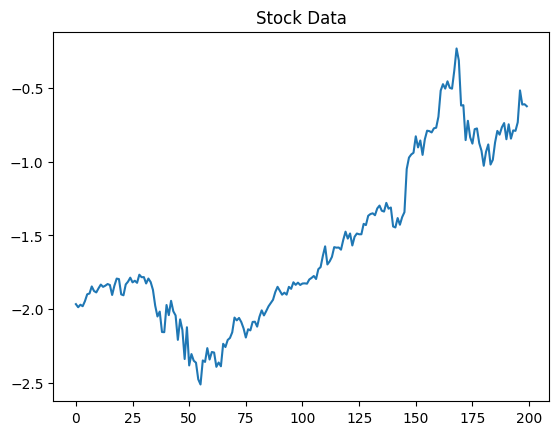

In [64]:
import yfinance as yf

df_stock = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

data_stock = df_stock['Close'].values
data_stock = (data_stock - data_stock.mean()) / data_stock.std()

plt.plot(data_stock[:200])
plt.title("Stock Data")

## Dataset 2

Text(0.5, 1.0, 'Temperature Data')

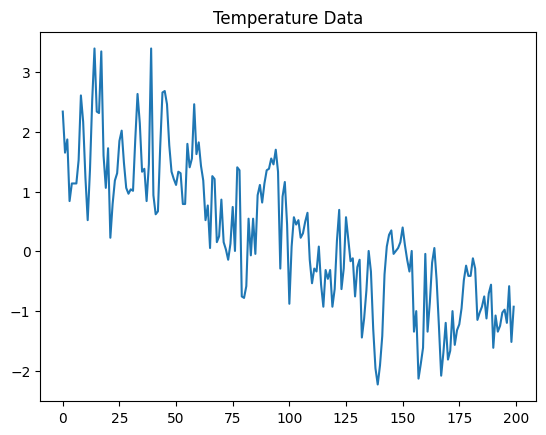

In [65]:
df_temp = pd.read_csv("/content/daily-min-temperatures.csv")

data_temp = df_temp['Temp'].values
data_temp = (data_temp - data_temp.mean()) / data_temp.std()

plt.plot(data_temp[:200])
plt.title("Temperature Data")

## Running Both Datsets


===== Stock Data =====
Sample Input: [[-1.96625788]
 [-1.98736882]
 [-1.97023399]
 [-1.98042803]
 [-1.94572427]
 [-1.89916382]
 [-1.89410307]
 [-1.84616897]
 [-1.87711309]
 [-1.88680119]]
Sample Output: [[-1.8586046 ]
 [-1.83337179]]
Final Input Shape: torch.Size([796, 10, 1])

Training MLP...
Epoch 0, Loss: 18.8396
Epoch 2, Loss: 3.2771
Epoch 4, Loss: 0.6944
Epoch 6, Loss: 0.6184
Epoch 8, Loss: 0.5702
MLP: MSE=0.0174, MAE=0.1090, RMSE=0.1317


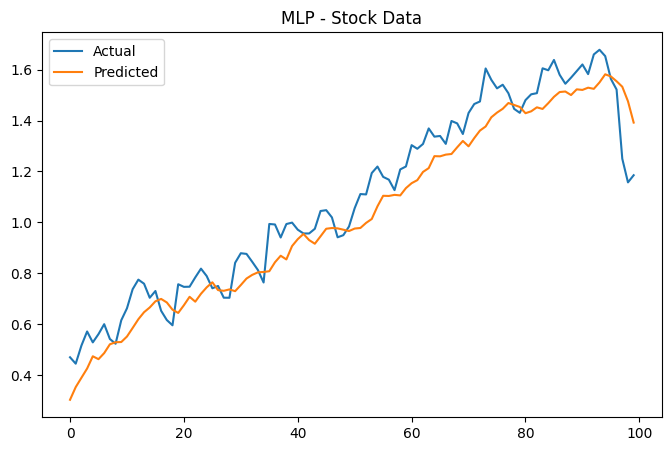


Training GRU...
Epoch 0, Loss: 22.7451
Epoch 2, Loss: 18.1374
Epoch 4, Loss: 12.1429
Epoch 6, Loss: 5.3390
Epoch 8, Loss: 2.6126
GRU: MSE=0.2289, MAE=0.4156, RMSE=0.4784


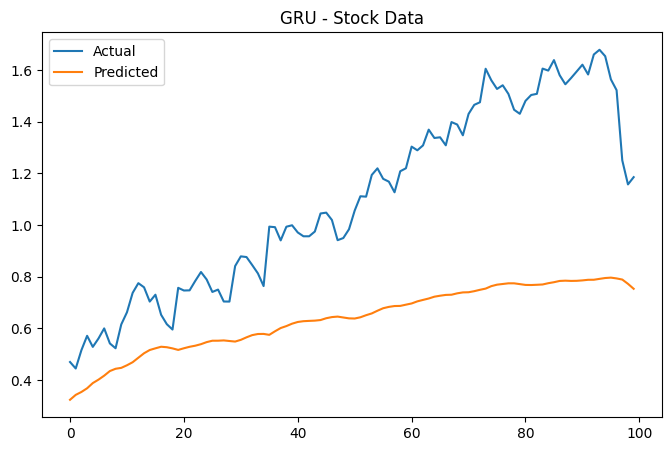


Training LSTM...
Epoch 0, Loss: 20.2698
Epoch 2, Loss: 17.6392
Epoch 4, Loss: 14.5184
Epoch 6, Loss: 9.0192
Epoch 8, Loss: 4.3896
LSTM: MSE=0.5447, MAE=0.6684, RMSE=0.7380


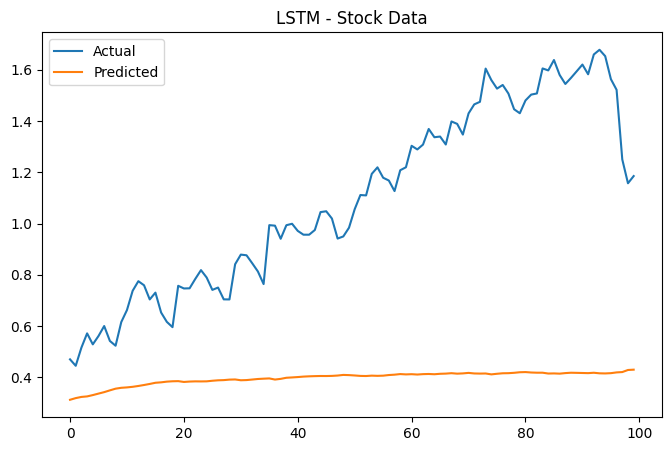


Training Transformer...
Epoch 0, Loss: 11.8043
Epoch 2, Loss: 5.5857
Epoch 4, Loss: 3.4686
Epoch 6, Loss: 1.7566
Epoch 8, Loss: 1.3236
Transformer: MSE=0.1360, MAE=0.2994, RMSE=0.3688


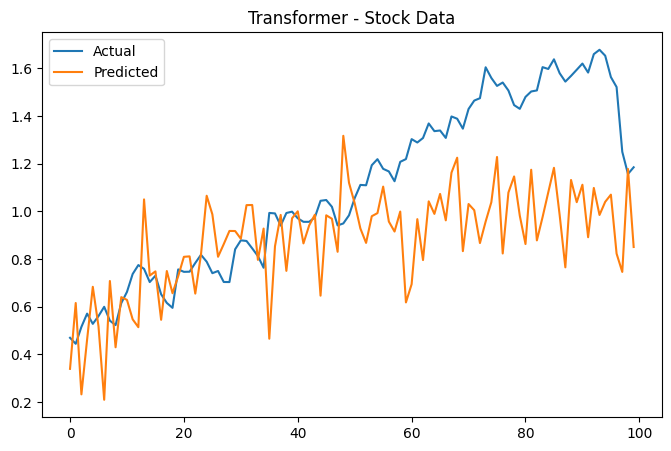

In [73]:
run_pipeline(data_stock, "Stock Data")


===== Temperature Data =====
Sample Input: [2.33888328 1.65113873 1.87219948 0.84058266 1.13533032 1.13533032
 1.13533032 1.52832721 2.60906864 2.16694715]
Sample Output: [1.23357954 0.52127269]
Final Input Shape: torch.Size([2911, 10, 1])

Training MLP...
Epoch 0, Loss: 62.0932
Epoch 2, Loss: 42.1749
Epoch 4, Loss: 39.9288
Epoch 6, Loss: 39.1508
Epoch 8, Loss: 38.8789
MLP: MSE=0.3551, MAE=0.4646, RMSE=0.5959


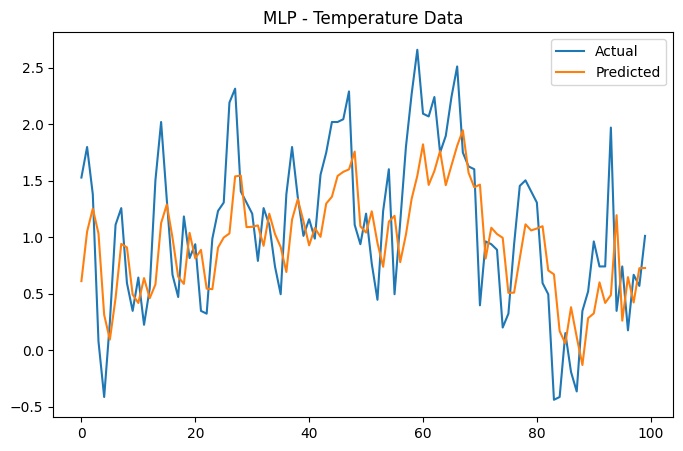

<Figure size 640x480 with 0 Axes>


Training GRU...
Epoch 0, Loss: 75.2385
Epoch 2, Loss: 42.7455
Epoch 4, Loss: 41.8370
Epoch 6, Loss: 41.0744
Epoch 8, Loss: 40.3998
GRU: MSE=0.3632, MAE=0.4698, RMSE=0.6026


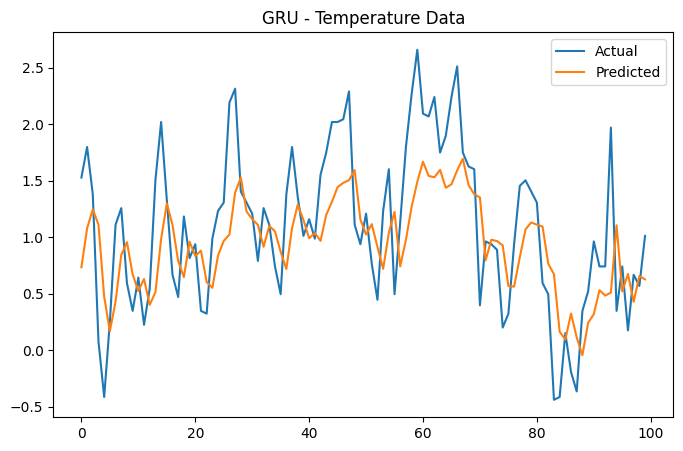

<Figure size 640x480 with 0 Axes>


Training LSTM...
Epoch 0, Loss: 84.2106
Epoch 2, Loss: 44.7469
Epoch 4, Loss: 43.1489
Epoch 6, Loss: 42.3097
Epoch 8, Loss: 41.6371
LSTM: MSE=0.3769, MAE=0.4776, RMSE=0.6139


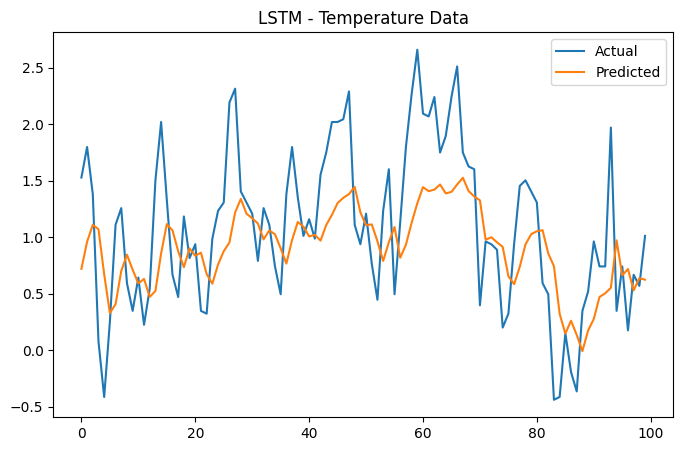

<Figure size 640x480 with 0 Axes>


Training Transformer...
Epoch 0, Loss: 65.3104
Epoch 2, Loss: 43.6018
Epoch 4, Loss: 41.6896
Epoch 6, Loss: 41.3008
Epoch 8, Loss: 41.1618
Transformer: MSE=0.3641, MAE=0.4705, RMSE=0.6034


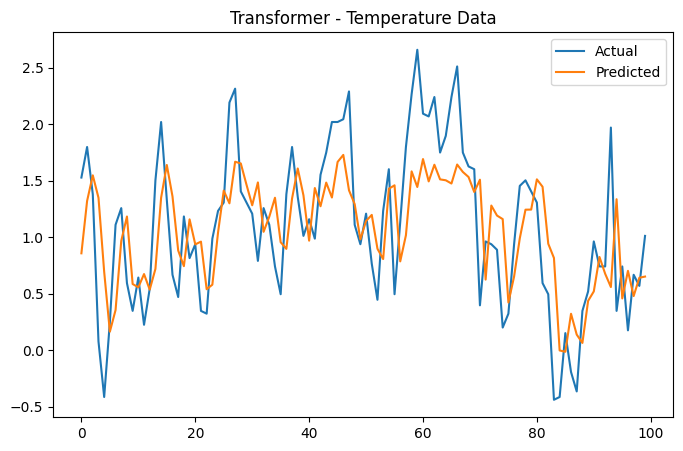

<Figure size 640x480 with 0 Axes>

In [69]:
run_pipeline(data_temp, "Temperature Data")

## Ablation Study

In [70]:
for ws in [5, 10, 20]:
    print(f"\nWindow Size: {ws}")

    # Create sequences
    X_temp, y_temp = create_sequences(data_stock, ws, prediction_horizon)

    split = int(0.8 * len(X_temp))

    X_train = torch.tensor(X_temp[:split], dtype=torch.float32)
    y_train = torch.tensor(y_temp[:split], dtype=torch.float32).squeeze(-1)

    X_test = torch.tensor(X_temp[split:], dtype=torch.float32)
    y_test = torch.tensor(y_temp[split:], dtype=torch.float32).squeeze(-1)

    # Fix shape
    if len(X_train.shape) == 2:
        X_train = X_train.unsqueeze(-1)
        X_test = X_test.unsqueeze(-1)

    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32)

    model = CustomGRU()

    train_model(model, loader, epochs=5)

    mse, mae, rmse, _, _ = evaluate(model, X_test, y_test)

    print(f"MSE={mse:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}")


Window Size: 5
Epoch 0, Loss: 19.5019
Epoch 2, Loss: 13.9376
Epoch 4, Loss: 8.1638
MSE=0.4095, MAE=0.5965, RMSE=0.6399

Window Size: 10
Epoch 0, Loss: 21.8555
Epoch 2, Loss: 17.4443
Epoch 4, Loss: 12.2928
MSE=0.9396, MAE=0.9364, RMSE=0.9693

Window Size: 20
Epoch 0, Loss: 18.9264
Epoch 2, Loss: 14.0940
Epoch 4, Loss: 8.2575
MSE=0.5373, MAE=0.6997, RMSE=0.7330


## ABLATION STUDY ANALYSIS

### The smallest window size (5) performed best because it focuses on recent data,
### which is more relevant in volatile time-series like stock prices.

### The original window size (10) performed worst, likely due to inclusion of
### unnecessary past information that introduces noise.

### A larger window size (20) provides more context but also increases noise,
### resulting in moderate performance.

### This shows that optimal window size depends on the nature of the data.